In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [4]:
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')


In [5]:
data=pd.read_csv('AIML Dataset.csv')
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [7]:
g=data.isnull().sum().sum()
print(f'Total number of missing values: {g}')

Total number of missing values: 0


In [8]:
data.shape
data['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

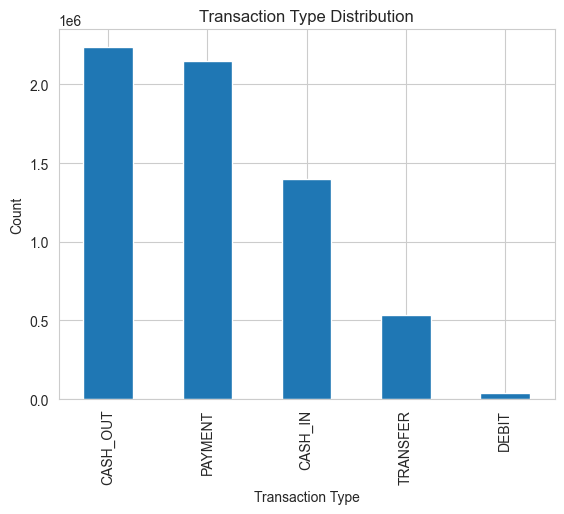

In [9]:
data['type'].value_counts().plot(kind='bar',title='Transaction Type Distribution')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.show()

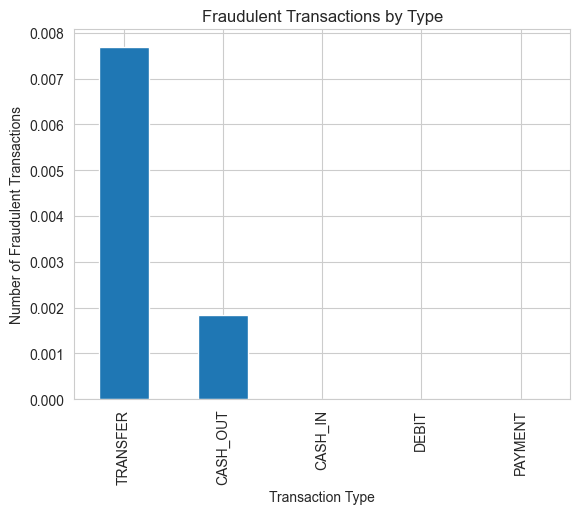

In [10]:
fraud_by_type=data.groupby('type')['isFraud'].mean().sort_values(ascending=False)
fraud_by_type.plot(kind='bar',title='Fraudulent Transactions by Type')
plt.xlabel('Transaction Type')
plt.ylabel('Number of Fraudulent Transactions')
plt.show()

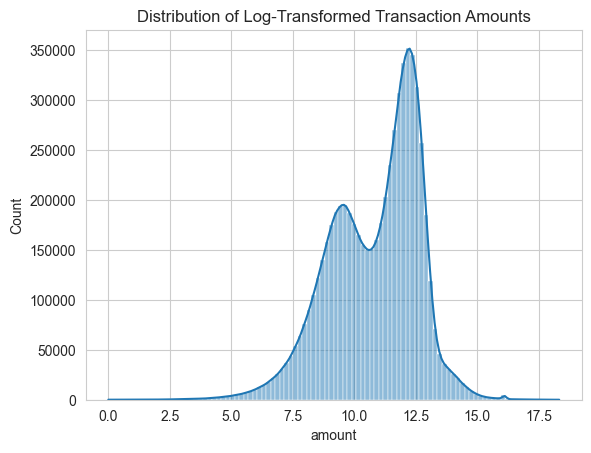

In [11]:
sns.histplot(np.log1p(data['amount']), bins=100, kde=True)
plt.title('Distribution of Log-Transformed Transaction Amounts')
plt.show()

In [12]:
data["balancedifforg"]=data["oldbalanceOrg"]-data["newbalanceOrig"]
data["balancediffdest"]=data["newbalanceDest"]-data["oldbalanceDest"]

In [13]:
(data["balancedifforg"]<0).sum()


np.int64(1399253)

In [14]:
(data["balancediffdest"]<0).sum()

np.int64(1238864)

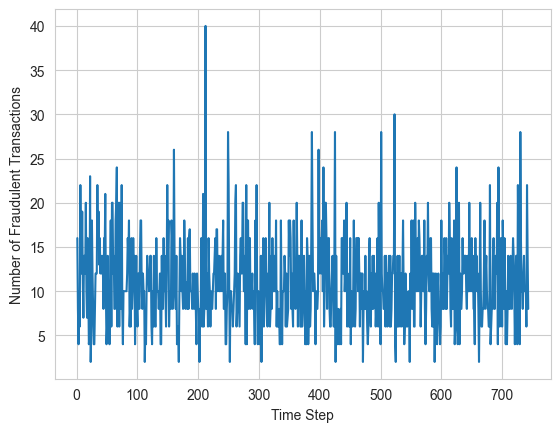

In [15]:
fraudsperstep=data[data['isFraud']==1]['step'].value_counts().sort_index()
plt.xlabel('Time Step')
plt.ylabel('Number of Fraudulent Transactions')
plt.plot(fraudsperstep.index, fraudsperstep.values)
plt.grid(True)
plt.show()

In [16]:
#since fraud doesnt depend on time(step) we drop that
data.drop('step',axis=1,inplace=True)

In [17]:
fraud_users=data[data['isFraud']==1]['nameOrig'].value_counts().sort_values(ascending=False).head(10)
fraud_users

nameOrig
C1118430673    1
C1280323807    1
C1305486145    1
C840083671     1
C1420196421    1
C1674778854    1
C43545501      1
C959102961     1
C1148860488    1
C1226129332    1
Name: count, dtype: int64

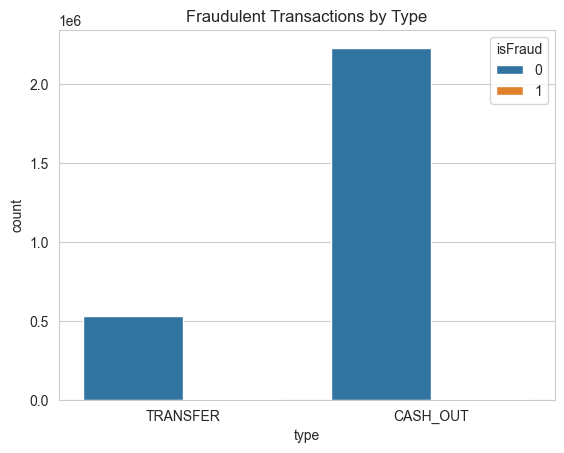

In [18]:
fraud_types=data[data['type'].isin(['TRANSFER','CASH_OUT'])]
fraud_types.value_counts()

sns.countplot(data=fraud_types,x="type",hue="isFraud")
plt.title('Fraudulent Transactions by Type')
plt.show()

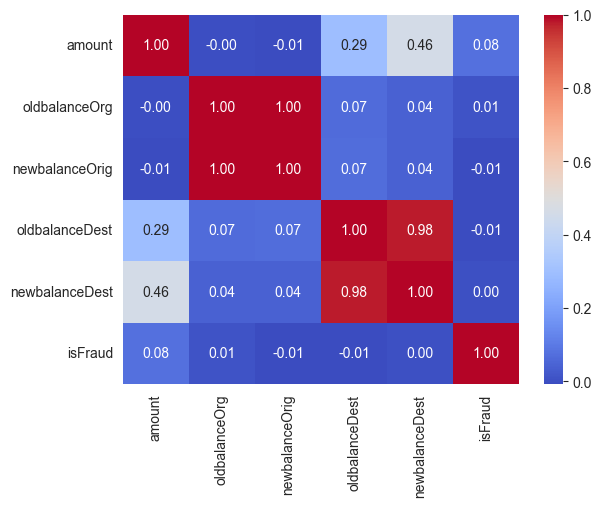

In [19]:
corr=data[['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest','isFraud']].corr()
sns.heatmap(corr,cmap='coolwarm',fmt='.2f', annot=True)
plt.show()

In [20]:
zero_after_transfer=data[(data['oldbalanceOrg']>0) & (data['newbalanceOrig']==0) & (data['type'].isin(['TRANSFER','CASH_OUT']))]
zero_after_transfer.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balancedifforg,balancediffdest
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,181.0,0.00
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,181.0,-21182.00
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,15325.0,46430.44
19,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,705.0,-22425.00
24,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,10835.0,2712905.89


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [22]:
data.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balancedifforg,balancediffdest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [23]:
data.drop(['nameOrig','nameDest','isFlaggedFraud'],axis=1,inplace=True)
data.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balancedifforg,balancediffdest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,181.00,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,181.00,-21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0.0


In [24]:
numeric=['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'balancedifforg', 'balancediffdest']
categorical=['type']

X=data.drop('isFraud',axis=1)
y=data['isFraud']

In [25]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,stratify=y)

In [26]:
preprocessor=ColumnTransformer(transformers=[
    ('num',StandardScaler(),numeric),('cat',OneHotEncoder(drop='first'),categorical)],remainder='drop')

pipeline=Pipeline(steps=[('preprocessor',preprocessor),('classifier',LogisticRegression(class_weight='balanced',max_iter=1000))])

In [27]:
pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount', 'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest',
                                                   'balancedifforg',
                                                   'balancediffdest']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['type'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [28]:
y_pred=pipeline.predict(X_test)


In [29]:
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1906322
           1       0.02      0.93      0.04      2464

    accuracy                           0.95   1908786
   macro avg       0.51      0.94      0.51   1908786
weighted avg       1.00      0.95      0.97   1908786

[[1808893   97429]
 [    174    2290]]


In [30]:
pipeline.score(X_test,y_test)

0.9488664522895705

In [31]:
import joblib
joblib.dump(pipeline,'fraud_detection_model.pkl')

['fraud_detection_model.pkl']

## Model Improvement: Random Forest Classifier
Now we'll enhance our model by:
1. Training a Random Forest Classifier
2. Comparing performance with Logistic Regression
3. Analyzing feature importance

In [32]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=20, class_weight='balanced', random_state=42, n_jobs=-1))
])

print("Training Random Forest...")
rf_pipeline.fit(X_train, y_train)
print("Training complete!")

Training Random Forest...
Training complete!


In [ ]:

y_pred_rf = rf_pipeline.predict(X_test)

print("=== Random Forest Results ===")
print(classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print(f"\nAccuracy: {rf_pipeline.score(X_test, y_test):.4f}")

=== Random Forest Results ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.75      0.92      0.83      2464

    accuracy                           1.00   1908786
   macro avg       0.88      0.96      0.91   1908786
weighted avg       1.00      1.00      1.00   1908786


Confusion Matrix:
[[1905577     745]
 [    208    2256]]

Accuracy: 0.9995


### Model Comparison & Evaluation Metrics

In [ ]:

models_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        pipeline.score(X_test, y_test),
        rf_pipeline.score(X_test, y_test)
    ]
})

print("=== Model Comparison ===")
print(models_comparison.to_string(index=False))
print("\nBest Model:", models_comparison.loc[models_comparison['Accuracy'].idxmax(), 'Model'])

=== Model Comparison ===
              Model  Accuracy
Logistic Regression  0.948866
      Random Forest  0.999501

Best Model: Random Forest


In [38]:
joblib.dump(rf_pipeline, 'fraud_detection_rf_model.pkl')

['fraud_detection_rf_model.pkl']